In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import seaborn as sns

In [3]:
data=pd.read_csv('4income.csv')
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
#basic que ans
#1.How many rows and columns are present in the dataset?
data.shape

(48842, 15)

In [5]:
#2.What are the data types of each column?
print(data.dtypes)


age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


In [14]:
#3.are there any null values in dataset?
#print(data.isnull().sum())
print((data == '?').sum())
#data.isnull().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [16]:
#4 find how many duplicate row exist?
print('Duplicate Rows:', data.duplicated().sum())


Duplicate Rows: 52


In [18]:
#univariate Analysis
#1 what is the ave age of people?
print("Average age:",data['age'].mean())

Average age: 38.64358543876172


In [23]:
#2.What is the minimum and maximum age?
print("max age=",data['age'].max())
print("min age=",data['age'].min())

max age= 90
min age= 17


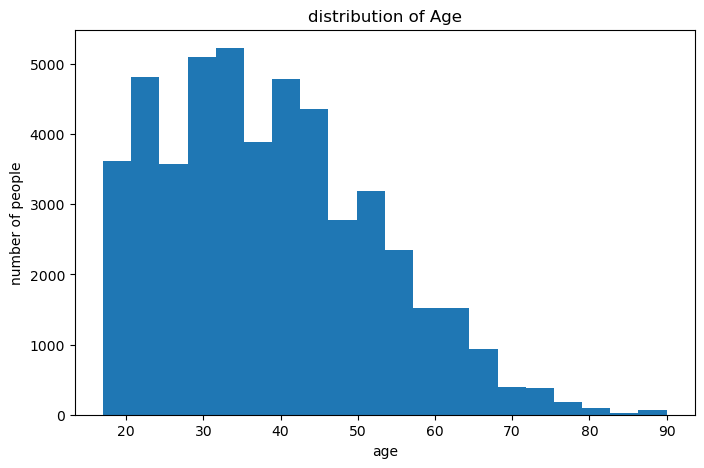

In [19]:
#3.What is the distribution of age?
pl.figure(figsize=(8,5))
pl.hist(data['age'],bins=20)
pl.xlabel('age')
pl.ylabel('number of people')
pl.title('distribution of Age')
pl.show()

In [24]:
#4.What is the average working hours per week?
print("average work hours=",data['hours-per-week'].mean())

average work hours= 40.422382375824085


In [ ]:
#5.Which numerical columns contain outliers?
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.show()


In [27]:
#6.What percentage of people have capital gain/loss?
#data.groupby('capital-gain')['capital-loss'].sum()
capital_gain_pct = (df['capital-gain'] > 0).mean() * 100
capital_loss_pct = (df['capital-loss'] > 0).mean() * 100

print('Capital Gain Percentage:', capital_gain_pct)
print('Capital Loss Percentage:', capital_loss_pct)

capital-gain
0        4273788
114            0
401            0
594            0
914            0
          ...   
25236          0
27828          0
34095          0
41310          0
99999          0
Name: capital-loss, Length: 123, dtype: int64

In [23]:
# *Categorical Columns*
#1.Which workclass category appears most frequently?
data['workclass'].value_counts().head(1)

workclass
Private    33906
Name: count, dtype: int64

In [24]:
#2.Which education level is most common?
data['education'].value_counts().head()

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
Name: count, dtype: int64

In [28]:
#3.Which occupation has highest count?
data['occupation'].value_counts().head()

occupation
Prof-specialty     6172
Craft-repair       6112
Exec-managerial    6086
Adm-clerical       5611
Sales              5504
Name: count, dtype: int64

gender
Male      32650
Female    16192
Name: count, dtype: int64


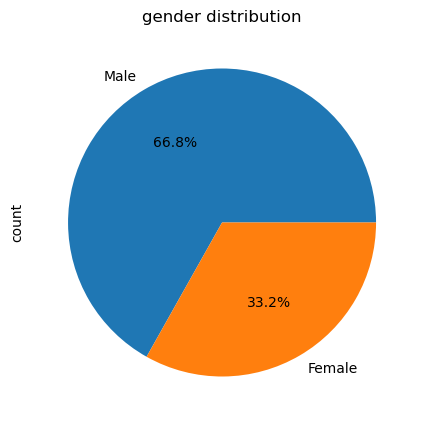

In [13]:
#4.Gender distribution in dataset?
print(data['gender'].value_counts())
pl.figure(figsize=(5,5))
data['gender'].value_counts().plot(kind='pie',autopct='%1.1f%%')
pl.title('gender distribution')
pl.show()


In [15]:
#5.Which country has highest number of records?
data['native-country'].value_counts().head(1)

native-country
United-States    43832
Name: count, dtype: int64

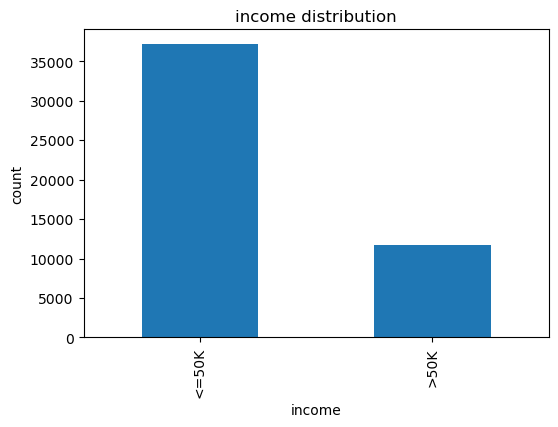

In [26]:
#6.Income class distribution (<=50K vs >50K)?-------------------->
data['income'].value_counts()
pl.figure(figsize=(6,4))
data['income'].value_counts().plot(kind='bar')
pl.xlabel('income')
pl.ylabel('count')
pl.title('income distribution')
pl.show()


In [30]:
#Bivariate Analysis (Two Columns)
#1.Does income depend on education level?
pd.crosstab(data['income'],data['education'])


education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
income,,,,,,,,,,,,,,,,
<=50K,1302,1720,609,239,482,893,715,1188,1539,4712,163,13281,1198,82,217,8815
>50K,87,92,48,8,27,62,41,413,522,3313,431,2503,1459,1,617,2063


In [38]:
#2.Which occupation has highest percentage of people earning >50K?
income=pd.crosstab(data['occupation'],data['income'],normalize='index')*100
income.sort_values(by='>50K',ascending=False)

# occupation_income = pd.crosstab(df['occupation'], df['income'],normalize='index') * 100
# occupation_income.sort_values(by='>50K', ascending=False)



income,<=50K,>50K
occupation,,
Exec-managerial,52.218206,47.781794
Prof-specialty,54.893065,45.106935
Armed-Forces,66.666667,33.333333
Protective-serv,68.667345,31.332655
Tech-support,70.954357,29.045643
Sales,73.201308,26.798692
Craft-repair,77.372382,22.627618
Transport-moving,79.575372,20.424628
Adm-clerical,86.312600,13.687400


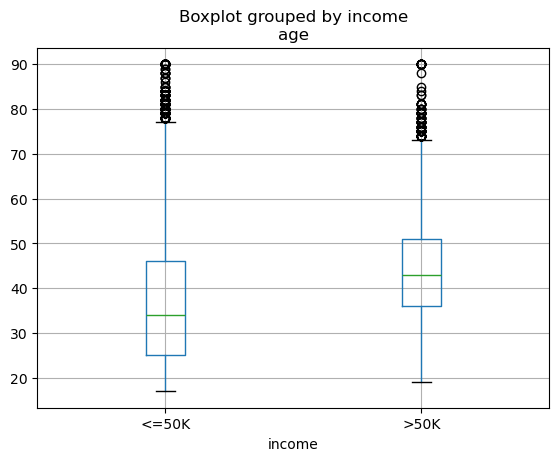

<Figure size 800x500 with 0 Axes>

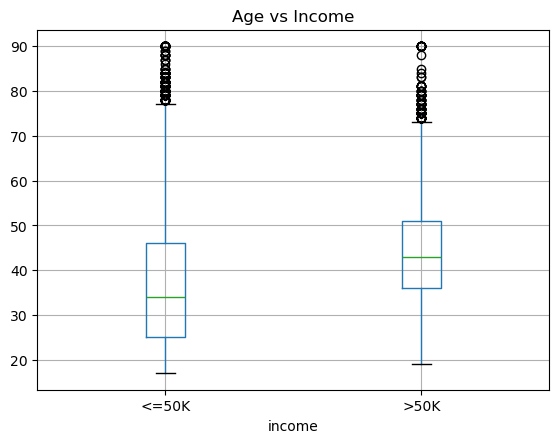

In [41]:
#3.Does age affect income?
data.boxplot(column='age', by='income')

pl.figure(figsize=(8,5))
data.boxplot(column='age', by='income')
pl.title('Age vs Income')
pl.suptitle('')
pl.show()

<Axes: xlabel='gender'>

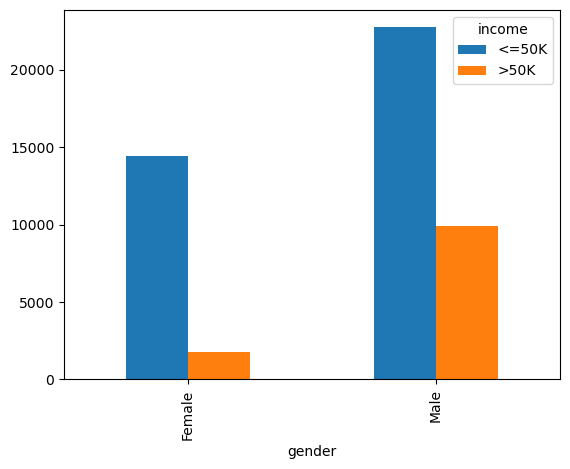

In [43]:
#4.Compare male vs female income distribution.
pd.crosstab(data['gender'],data['income']).plot(kind='bar')

In [50]:
#5.Does marital status affect income?
#pd.crosstab(data['marital-status'],data['income'])

marital_income = pd.crosstab(data['marital-status'], data['income'])

print(marital_income)

if marital_income['>50K'].max() > 5000:
    print("Yes, marital status affects income.")
else:
    print("No, marital status does not affect income.")

income                 <=50K  >50K
marital-status                    
Divorced                5962   671
Married-AF-spouse         23    14
Married-civ-spouse     12395  9984
Married-spouse-absent    570    58
Never-married          15384   733
Separated               1431    99
Widowed                 1390   128
Yes, marital status affects income.


In [53]:
#6.Which workclass earns highest income on average?
work_class=pd.crosstab(data['workclass'],data['income'],normalize='index')*100
work_class.sort_values(by='>50K',ascending=False)


income,<=50K,>50K
workclass,,
Self-emp-inc,44.660767,55.339233
Federal-gov,60.824022,39.175978
Local-gov,70.440051,29.559949
Self-emp-not-inc,72.112895,27.887105
State-gov,73.245835,26.754165
Private,78.213296,21.786704
Without-pay,90.476190,9.523810
?,90.532333,9.467667
Never-worked,100.000000,0.000000


<Figure size 800x500 with 0 Axes>

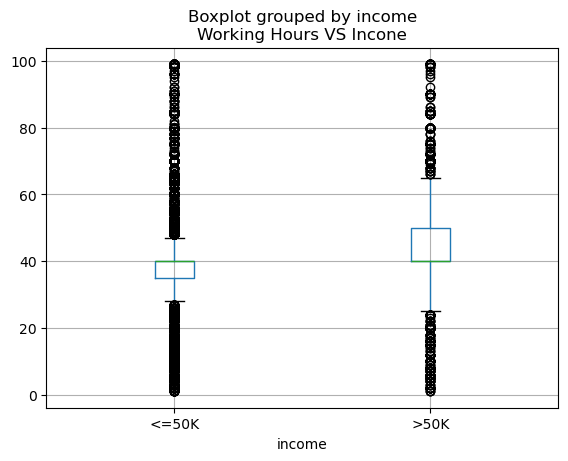

In [55]:
#7. Do people working more hours earn more income?
pl.figure(figsize=(8,5))
data.boxplot(column='hours-per-week',by='income')
pl.title('Working Hours VS Incone')
pl.show()

<Figure size 800x500 with 0 Axes>

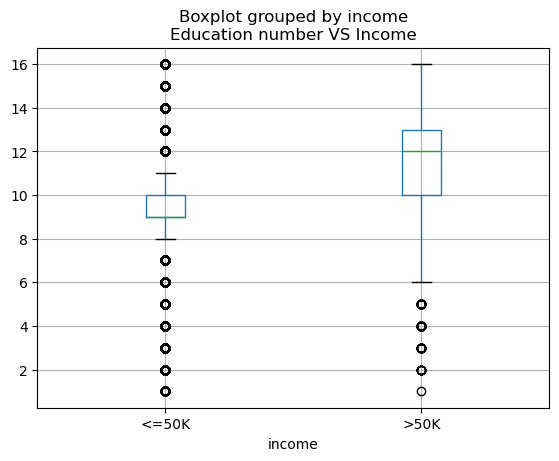

In [56]:
#8. Relationship between education number and salary?
pl.figure(figsize=(8,5))
data.boxplot(column='educational-num',by='income')
pl.title("Education number VS Income")
pl.show()

In [58]:
#9.Which race category has highest income proportion?
race=pd.crosstab(data['race'],data['income'],normalize='index')*100
race.sort_values(by='>50K',ascending=False)

income,<=50K,>50K
race,,
Asian-Pac-Islander,73.074391,26.925609
White,74.601312,25.398688
Other,87.684729,12.315271
Black,87.918890,12.081110
Amer-Indian-Eskimo,88.297872,11.702128


In [61]:
#Multivariate Analysis
#1. How do age, education, and hours-per-week together affect income?
# result=data.groupby(['education','income'])[['age','hours-per-week']].mean()
# result


In [69]:
#2. Which combination of workclass + education gives highest income?
result=pd.crosstab([data['workclass'],data['education']],data['income'],normalize='index')*100
result.sort_values(by='>50K',ascending=False).head(10)

,income,<=50K,>50K
workclass,education,,
Self-emp-inc,Prof-school,5.426357,94.573643
Federal-gov,Doctorate,13.636364,86.363636
Self-emp-inc,Doctorate,16.363636,83.636364
Self-emp-not-inc,Prof-school,20.918367,79.081633
Federal-gov,Prof-school,21.052632,78.947368
State-gov,Doctorate,26.400000,73.600000
Self-emp-inc,Masters,27.678571,72.321429
Private,Doctorate,28.897338,71.102662
Federal-gov,Masters,30.909091,69.090909


In [75]:
#3.Does gender + occupation impact salary?
pd.crosstab([data['gender'],data['occupation']],data['income'])

income                    <=50K  >50K
gender occupation                    
Female ?                   1198    75
       Adm-clerical        3460   309
       Craft-repair         290    33
       Exec-managerial     1327   421
       Farming-fishing       92     3
       Handlers-cleaners    246     8
       Machine-op-inspct    776    28
       Other-service       2620    78
       Priv-house-serv      225     3
       Prof-specialty      1660   582
       Protective-serv      107    15
       Sales               1813   134
       Tech-support         495    67
       Transport-moving     114    13
Male   ?                   1346   190
       Adm-clerical        1383   459
       Armed-Forces          10     5
       Craft-repair        4439  1350
       Exec-managerial     1851  2487
       Farming-fishing     1225   170
       Handlers-cleaners   1688   130
       Machine-op-inspct   1874   344
       Other-service       2099   126
       Priv-house-serv       14     0
       Prof-specialty      1728  2202
       Protective-serv      568   293
       Sales               2216  1341
       Tech-support         531   353
       Transport-moving    1760   468

In [4]:
#4.Which factors are most correlated with high income?
# Step 1: Convert income column into a binary numeric column (0 and 1)
data['income_binary'] = data['income'].map({'<=50K': 0, '>50K': 1})

# Step 2: Select numerical columns to calculate correlation
numeric_columns = data.select_dtypes(include=['int64', 'float64'])

# Step 3: Find correlation with the income column
income_correlation = numeric_columns.corr()['income_binary'].sort_values(ascending=False)

# Display the results
print(income_correlation)


income_binary      1.000000
educational-num    0.332613
age                0.230369
hours-per-week     0.227687
capital-gain       0.223013
capital-loss       0.147554
fnlwgt            -0.006339
Name: income_binary, dtype: float64
